In [29]:

%load_ext autoreload
%autoreload 2

In [30]:
import rasterio
import numpy as np
from pathlib import Path
from acc import  get_user_accuracy, get_producer_accuracy
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
import matplotlib.pyplot as plt
from dem_stitcher.rio_window import read_raster_from_window
from colormap_utils import add_random_colors_colorbar, create_random_colormap_matplotlib
from basemaps import get_basemap_for_rasterio
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
from colormap_utils import add_continuous_colorbar_to_axes
from rio_utils import crop_to_bounds
from rasterio.crs import CRS


In [31]:
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()

In [65]:
KEY = '50NPL_geometry'
KEY = '50NPL_high_low_labels'
KEY = '12STA_greenup'
KEY = '22MGB_clearing'
KEY = '50SMF_buildings_1'
KEY = '52TDP_buildings_s1_better'
KEY = '52TDP_buildings_s1_better_2'
KEY = '52TDP_new_water'
KEY = '50NPL_geometry'
KEY = '14RNU_water_recession'
KEY = '22MGB_logging_short'
KEY = '53KKU_water_new'
KEY = '19TBG_building_us'
KEY = '53LKC_inundated_vegetation_aus'
KEY = '49RGN_aquaculture_china'
KEY = '36PVR_forest_loss_natural_sudan'
KEY = '20LNJ_bolivia_fire'
KEY = '19TBG_forest_clearing_us'
KEY = '19TBG_building_us'
KEY = '53KKU_water_new_2'
KEY = '53KKU_water_new_3'


In [74]:
from bounds_config import BOUNDS

bounds = BOUNDS[KEY]
mgrs_tile_id = KEY.split('_')[0]

In [75]:
PNG_DIR = Path('pngs')
CASE_PNG_DIR = PNG_DIR / KEY
CASE_PNG_DIR.mkdir(exist_ok=True, parents=True)

In [76]:
agg_dirs_parent = Path('aggregated_validation_dist_2024')
agg_dirs_parent.exists()

True

In [77]:
agg_dir = list(agg_dirs_parent.glob(f'*{mgrs_tile_id}/'))[0]
agg_dir

PosixPath('aggregated_validation_dist_2024/waternew__53KKU')

In [78]:
def get_paths(agg_dir: Path):
    veg_status_path = list(agg_dir.glob('dist_hls_veg_*.tif'))[0]
    gen_status_path = list(agg_dir.glob('dist_hls_gen_*.tif'))[0]
    dist_s1_path = list(agg_dir.glob('dist_s1_agg*.tif'))[0]
    dist_s1_count = list(agg_dir.glob('*_count_2024_s1.tif'))[0]
    dist_hls_count = list(agg_dir.glob('*_count_2024_hls.tif'))[0]
    lc_path = list(agg_dir.glob('*glad_lc_mask.tif'))[0]
    return {'veg_status': veg_status_path,
            'gen_status': gen_status_path,
            'dist_s1': dist_s1_path,
            'dist_s1_count': dist_s1_count,
            'dist_hls_count': dist_hls_count,
            'lc': lc_path}


In [79]:
path_dict = get_paths(agg_dir)

In [80]:
path_dict = get_paths(agg_dir)
veg_status, p_veg = read_raster_from_window(path_dict['veg_status'], bounds)
veg_status = veg_status[0, ...]
gen_status, p_gen = read_raster_from_window(path_dict['gen_status'], bounds)
gen_status = gen_status[0, ...]
dist_s1, p_s1 = read_raster_from_window(path_dict['dist_s1'], bounds)
dist_s1 = dist_s1[0, ...]
dist_s1_count, p_s1_count = read_raster_from_window(path_dict['dist_s1_count'], bounds)
dist_s1_count = dist_s1_count[0, ...]
dist_hls_count, p_hls_count = read_raster_from_window(path_dict['dist_hls_count'], bounds)
dist_hls_count = dist_hls_count[0, ...]
lc, p_lc = read_raster_from_window(path_dict['lc'], bounds)
lc = lc[0, ...]

(np.float64(-0.5), np.float64(98.5), np.float64(74.5), np.float64(-0.5))

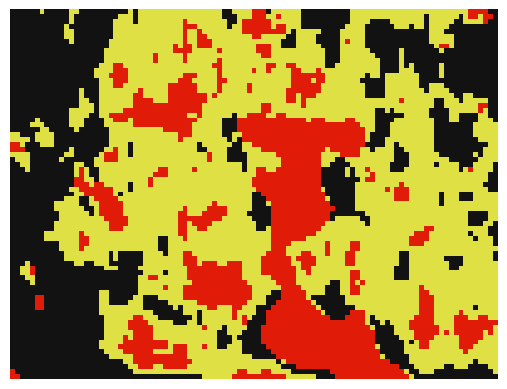

In [81]:
fig, ax = plt.subplots()
ax.imshow(dist_s1, cmap=dist_cmap, norm=dist_norm)
ax.axis('off')

In [82]:
dist_s1_all = (np.isin(dist_s1, [3, 6])).astype(np.uint8)
dist_veg_all = (np.isin(veg_status, [3, 6])).astype(np.uint8)
dist_gen_all = (np.isin(gen_status, [3, 6])).astype(np.uint8)

diff_veg_fp = (dist_s1_all == 1) & (dist_veg_all == 0)
diff_veg_fn = (dist_s1_all == 0) & (dist_veg_all == 1)

diff_gen_fp = (dist_s1_all == 1) & (dist_gen_all == 0)
diff_gen_fn = (dist_s1_all == 0) & (dist_gen_all == 1)

all_diff_veg = np.zeros_like(dist_s1)
all_diff_veg[diff_veg_fp] = 1
all_diff_veg[diff_veg_fn] = 2

all_diff_gen = np.zeros_like(dist_s1)
all_diff_gen[diff_gen_fp] = 1
all_diff_gen[diff_gen_fn] = 2


In [83]:
rnd_cmap, rnd_norm = create_random_colormap_matplotlib(background_val=0)


(np.float64(-0.5), np.float64(98.5), np.float64(74.5), np.float64(-0.5))

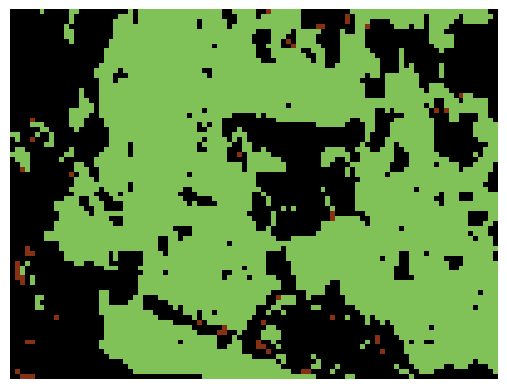

In [84]:
fig, ax = plt.subplots()
ax.imshow(all_diff_veg, cmap=rnd_cmap, norm=rnd_norm)
ax.axis('off')

In [85]:
X_esri, p_esri = get_basemap_for_rasterio(*bounds, zoom='auto')
X_esri_r, _ = crop_to_bounds(X_esri, p_esri, bounds, CRS.from_epsg(4326))
X_esri_r = X_esri_r.transpose(1, 2, 0)[...,:3] / 255.
X_esri_r.shape

(485, 657, 3)

In [86]:
from rio_utils import crop_to_bounds
from rasterio.crs import CRS
X_google, p_google = get_basemap_for_rasterio(*bounds, zoom='auto', source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}')
X_google_r, _ = crop_to_bounds(X_google, p_google, bounds, CRS.from_epsg(4326))
X_google_r = X_google_r.transpose(1, 2, 0)[...,:3] / 255.
X_google_r.shape

(485, 657, 3)

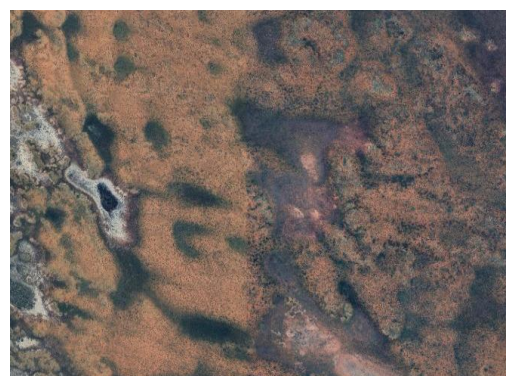

In [87]:
fig, ax = plt.subplots()
ax.imshow(X_google_r)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'google_{KEY}_hi.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

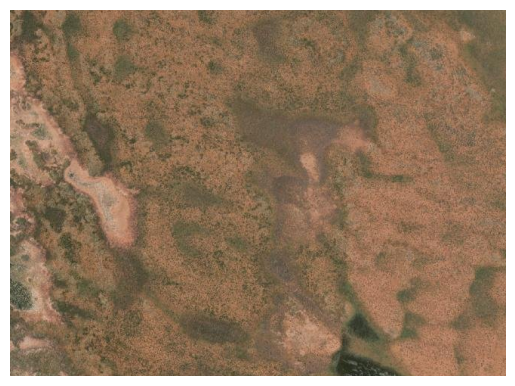

In [88]:
fig, ax = plt.subplots()
ax.imshow(X_esri_r)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'esri_{KEY}_hi.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

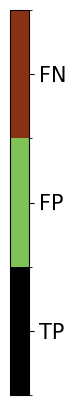

In [89]:
fig, ax = plt.subplots(figsize=(.25, 5))

add_random_colors_colorbar(ax, color_val_map={0: 'TP', 1: 'FP', 2: 'FN'}, cmap=rnd_cmap, fontsize=15)

plt.savefig(CASE_PNG_DIR / f'diff_colorbar.png', dpi=1_000, bbox_inches='tight', pad_inches=0.1)

In [90]:
import pystac_client
from dist_s1.aws import rasterio_anon_s3_env
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from shapely.geometry import shape

def search_stac_assets(bbox, 
                       time_start, 
                       time_stop, 
                       collection="sentinel-2-l2a",
                       cloud_cover_max=5,
                       max_items=None):
    catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    
    search = catalog.search(
        collections=[collection],
        bbox=bbox,
        datetime=f"{time_start}/{time_stop}",
        query={"eo:cloud_cover": {"leq": cloud_cover_max}},
        max_items=max_items)
    
    results = [r for r in search.get_items()]
    links = [{
        **{'id': r.id},
        **r.properties, 
        **{'geometry': shape(r.geometry)},
        **{name: asset.href for name, asset in r.assets.items()}
    } for r in results]
    return links

@rasterio_anon_s3_env
def stream_one_stack_url(asset_url, bbox):
    with rasterio.open(asset_url) as src:
        left, bottom, right, top = transform_bounds("EPSG:4326", src.crs, *bbox)
        window = from_bounds(left, bottom, right, top, transform=src.transform)
        
        arr = src.read(1, window=window)
        
        profile = src.profile.copy()
        profile.update({
            "height": int(window.height),
            "width": int(window.width),
            "transform": src.window_transform(window)
        })
        
        return arr, profile

In [91]:
results = search_stac_assets(bounds, "2023-01-01", "2023-03-30")

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [92]:
# sr = results[0]
# r, p = stream_one_stack_url(sr['red'], bounds)
# g, p = stream_one_stack_url(sr['green'], bounds)
# b, p = stream_one_stack_url(sr['blue'], bounds)
# rgb = np.stack([r, g, b], axis=-1)


In [ ]:
def get_rgb_image(result, bbox, rgb=['nir', 'red', 'green'], ps=None):
    r, _ = stream_one_stack_url(result[rgb[0]], bbox)
    g, _ = stream_one_stack_url(result[rgb[1]], bbox)
    b, _ = stream_one_stack_url(result[rgb[2]], bbox)
    
    rgb = np.dstack((r, g, b))
    
    if ps is None:
        p2, p98 = np.percentile(rgb, (2, 98))
    else:
        p2, p98 = ps
    
    print(p2, p98)
    rgb_stretched = np.clip((rgb - p2) / (p98 - p2), 0, 1)
    
    return rgb_stretched

In [94]:
results[0]

{'id': 'S2A_52KHD_20230329_0_L2A',
 'created': '2023-03-29T07:29:47.688Z',
 'platform': 'sentinel-2a',
 'constellation': 'sentinel-2',
 'instruments': ['msi'],
 'eo:cloud_cover': 0,
 'mgrs:utm_zone': 52,
 'mgrs:latitude_band': 'K',
 'mgrs:grid_square': 'HD',
 'grid:code': 'MGRS-52KHD',
 'view:sun_azimuth': 53.7249738605092,
 'view:sun_elevation': 54.2044431108983,
 's2:degraded_msi_data_percentage': 0.0224,
 's2:nodata_pixel_percentage': 49.769744,
 's2:saturated_defective_pixel_percentage': 0,
 's2:dark_features_percentage': 0,
 's2:cloud_shadow_percentage': 0,
 's2:vegetation_percentage': 0.924472,
 's2:not_vegetated_percentage': 97.370577,
 's2:water_percentage': 0.362761,
 's2:unclassified_percentage': 1.342189,
 's2:medium_proba_clouds_percentage': 0,
 's2:high_proba_clouds_percentage': 0,
 's2:thin_cirrus_percentage': 0,
 's2:snow_ice_percentage': 0,
 's2:product_type': 'S2MSI2A',
 's2:processing_baseline': '05.09',
 's2:product_uri': 'S2A_MSIL2A_20230329T011721_N0509_R088_T52KHD

1 S2A_53KKU_20230329_0_L2A
394.0 1584.0


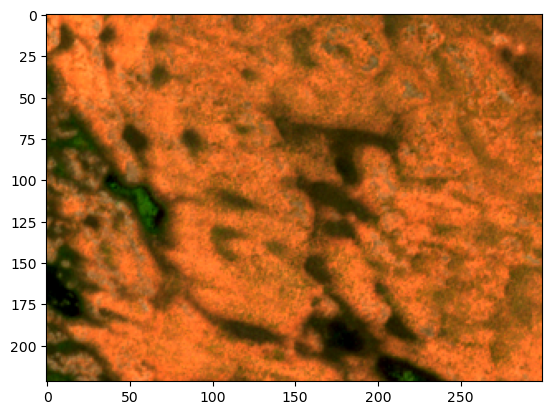

2 S2B_52KHD_20230324_1_L2A
416.0 1576.0


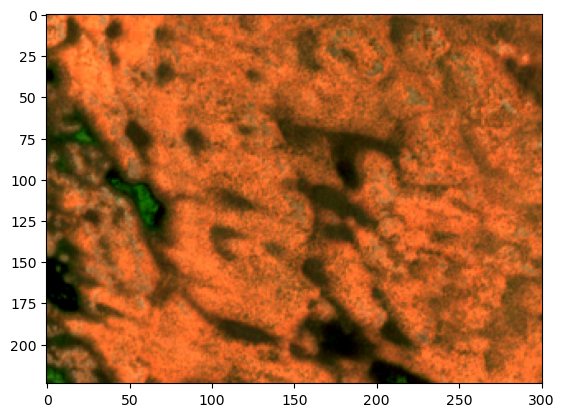

3 S2B_53KKU_20230324_1_L2A
419.0 1584.0


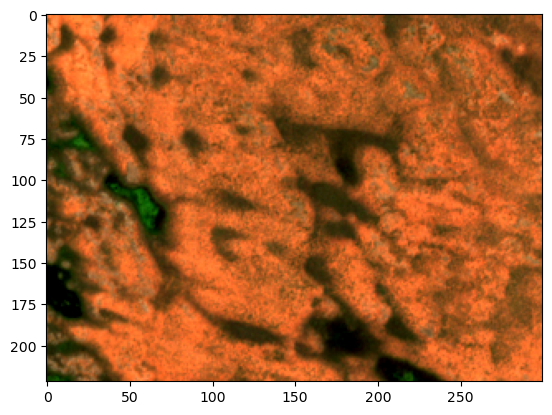

4 S2A_52KHD_20230319_0_L2A
374.0 1560.0


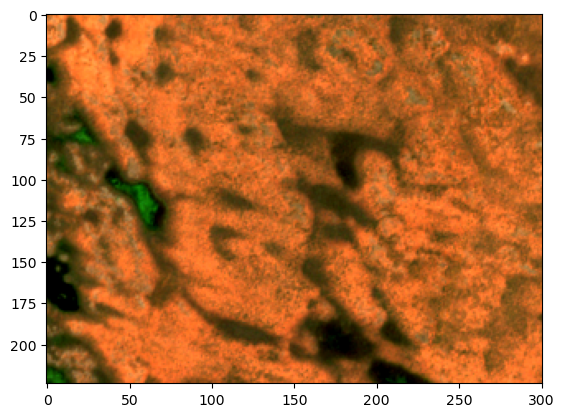

5 S2A_53KKU_20230319_0_L2A
375.0 1568.0


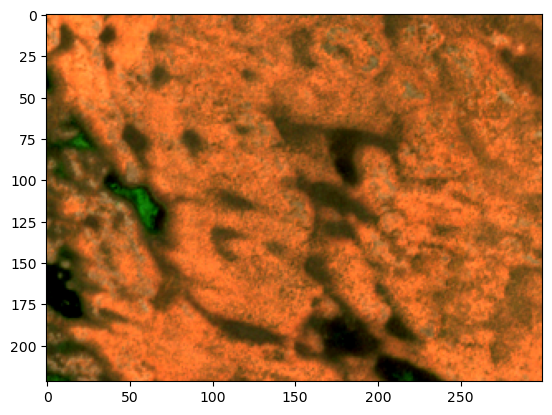

6 S2B_52KHD_20230317_1_L2A
338.0 1470.0


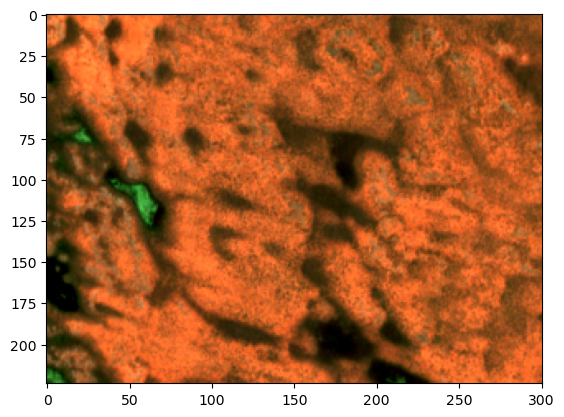

7 S2B_53KKU_20230317_0_L2A
338.0 1472.0


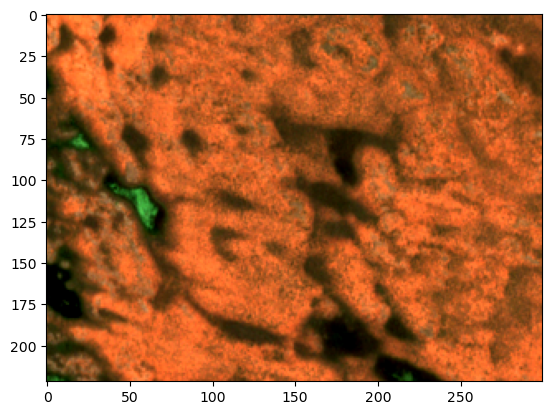

8 S2B_52KHD_20230314_0_L2A
381.0 1598.0


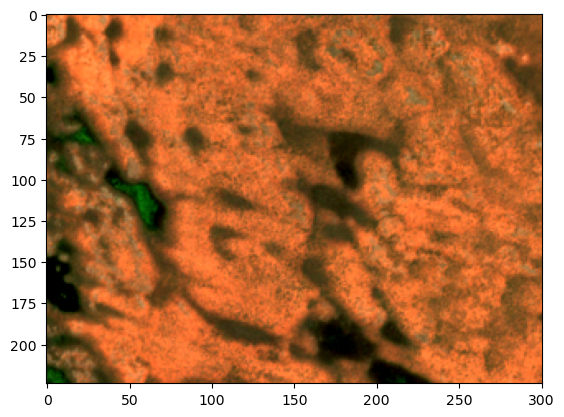

9 S2B_53KKU_20230314_0_L2A
382.0 1604.0


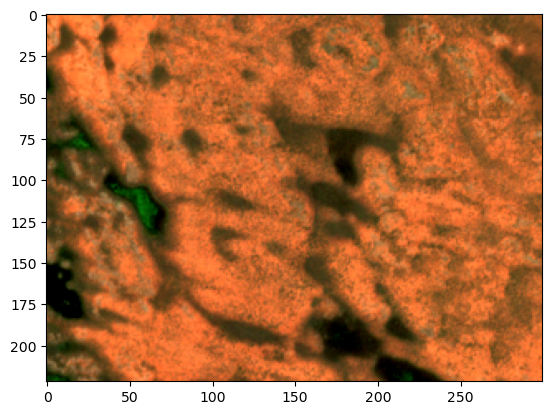

In [95]:
for i in range(1, 10):
    print(i, results[i]['id'])
    rgb = get_rgb_image(results[i], bounds, 
                        #rgb=['swir16', 'nir08', 'rededge1']
                        rgb=['red', 'green', 'blue']
                        )
    plt.imshow(rgb)
    plt.show()


In [98]:
results_2024 = search_stac_assets(bounds, "2024-01-01", "2024-03-30")


5 S2A_53KKU_20240323_0_L2A
7608.0 9264.0


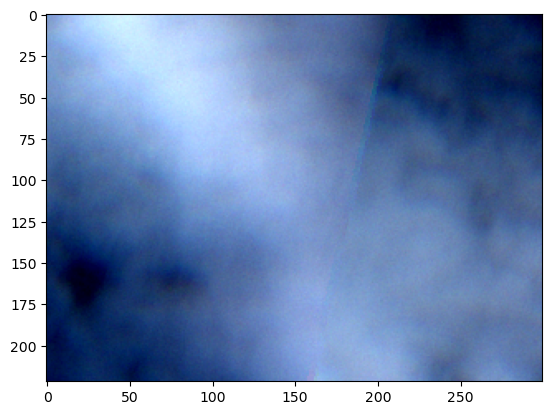

6 S2B_52KHD_20240321_0_L2A
7632.0 8840.0


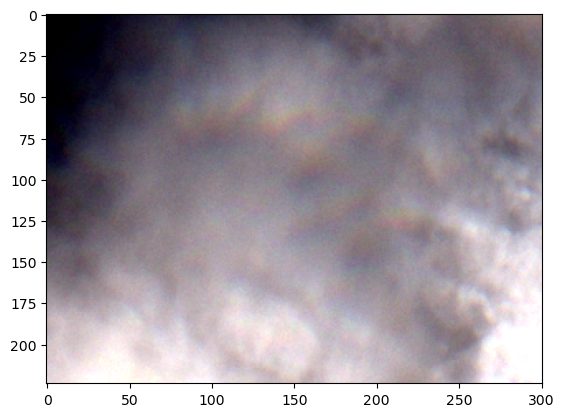

7 S2B_53KKU_20240321_0_L2A
7648.0 8840.0


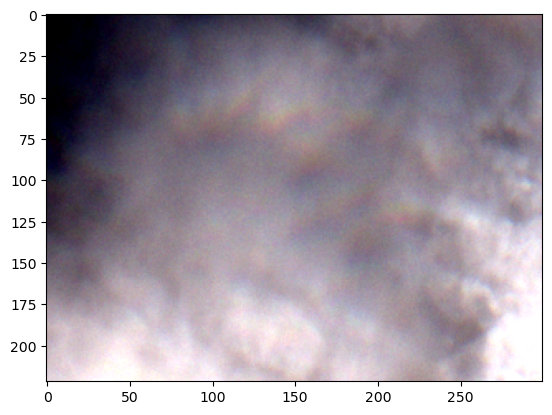

8 S2B_52KHD_20240318_0_L2A
225.0 1762.0


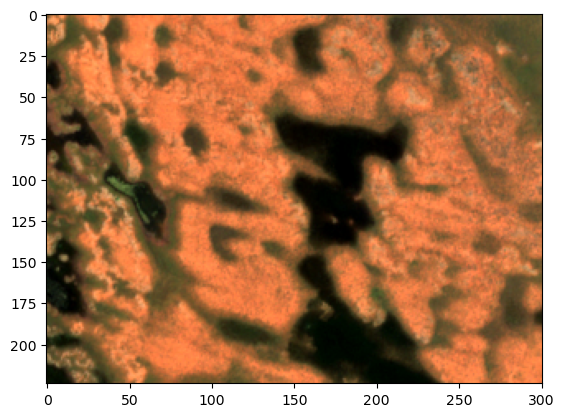

9 S2B_53KKU_20240318_0_L2A
236.0 1766.0


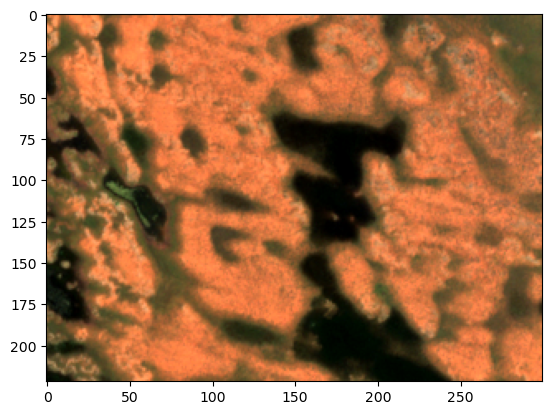

In [99]:
for i in range(5, 10):
    print(i, results_2024[i]['id'])
    rgb = get_rgb_image(results_2024[i], bounds, 
                        rgb=['red', 'green', 'blue']
                        #rgb=['swir16', 'nir08', 'rededge1']
                        )
    plt.imshow(rgb)
    plt.show()


S2B_20LNJ_20241227_0_L2A


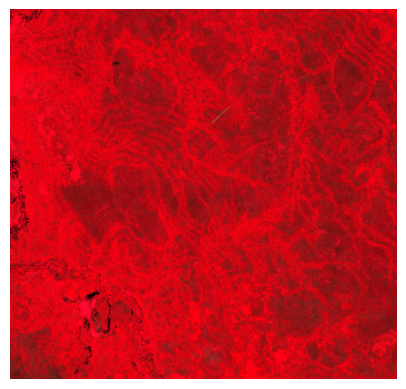

In [ ]:
index = 2
fig, ax = plt.subplots()
id = results_2024[index]['id']
rgb = get_rgb_image(results_2024[index], 
                    bounds, 
                    #rgb=['red', 'green', 'blue']
                    )
ax.imshow(rgb)
ax.axis('off')
print(id)
plt.savefig(CASE_PNG_DIR / f's2_post_2024_{id}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

S2A_20LNJ_20231228_0_L2A


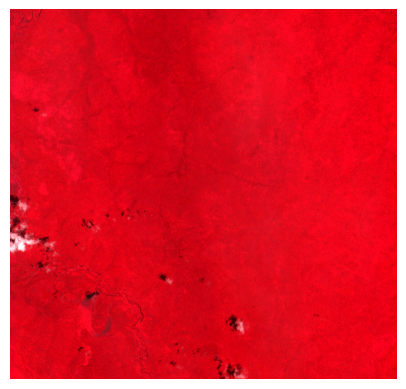

In [ ]:
index = 1
fig, ax = plt.subplots()
id = results[index]['id']
rgb = get_rgb_image(results[index], 
                    bounds, 
                    #rgb=['red', 'green', 'blue']
                    )
ax.imshow(rgb)
ax.axis('off')
print(id)
plt.savefig(CASE_PNG_DIR / f's2_pre_2023_{id}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)